# 04. Baseline Models

Train logistic regression and tree-based baselines to establish a performance reference.

## Baseline workflow

This notebook is designed to compare:
- a dummy majority-class baseline,
- logistic regression on scaled features,
- a random forest baseline on raw features,
- and threshold-based evaluation for the fraud class.


In [14]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [15]:
DATA_PATH = "../data/raw/creditcard.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)

(284807, 31)


In [16]:
X = df.drop(columns=["Class"])
y = df["Class"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)
print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)


Train: (199364, 30)
Validation: (42721, 30)
Test: (42722, 30)
Scaled train shape: (199364, 30)
Scaled test shape: (42722, 30)


In [18]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    print(f"\n{'=' * 50}")
    print(model_name)
    print(f"{'=' * 50}")

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"PR-AUC   : {pr_auc:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            zero_division=0
        )
    )

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    }


Dummy Classifier
Accuracy : 0.9983
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000
ROC-AUC  : 0.5000
PR-AUC   : 0.0017

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.00      0.00      0.00        74

    accuracy                           1.00     42722
   macro avg       0.50      0.50      0.50     42722
weighted avg       1.00      1.00      1.00     42722



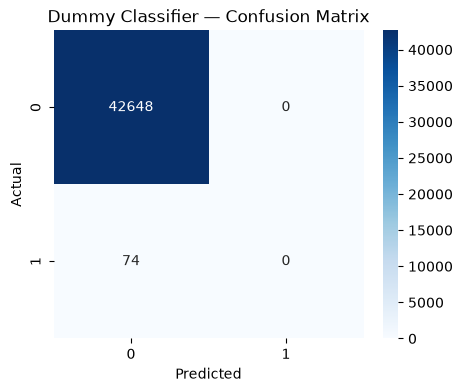

In [20]:
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train, y_train)

dummy_pred = dummy_model.predict(X_test)

dummy_prob = dummy_model.predict_proba(X_test)[:, 1]

dummy_results = evaluate_model(
    "Dummy Classifier",
    y_test,
    dummy_pred,
    dummy_prob
)


Logistic Regression
Accuracy : 0.9993
Precision: 0.9216
Recall   : 0.6351
F1-score : 0.7520
ROC-AUC  : 0.9565
PR-AUC   : 0.7499

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.92      0.64      0.75        74

    accuracy                           1.00     42722
   macro avg       0.96      0.82      0.88     42722
weighted avg       1.00      1.00      1.00     42722



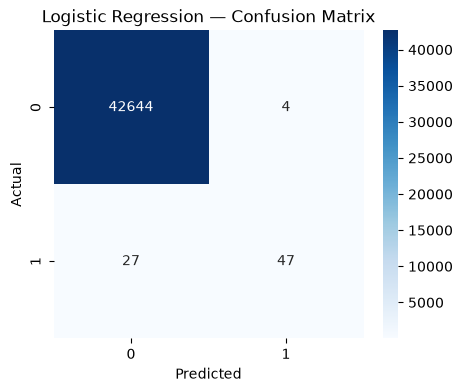

In [21]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_pred = logistic_model.predict(X_test_scaled)
logistic_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

logistic_results = evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_pred,
    logistic_prob
)


Random Forest
Accuracy : 0.9996
Precision: 0.9524
Recall   : 0.8108
F1-score : 0.8759
ROC-AUC  : 0.9300
PR-AUC   : 0.8262

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.95      0.81      0.88        74

    accuracy                           1.00     42722
   macro avg       0.98      0.91      0.94     42722
weighted avg       1.00      1.00      1.00     42722



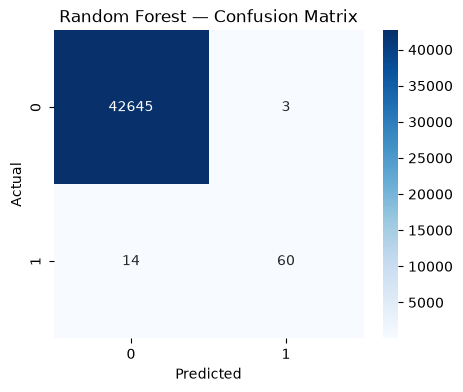

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Dummy Classifier,0.998268,0.000000,0.000000,0.000000,0.500000,0.001732
1,Logistic Regression,0.999274,0.921569,0.635135,0.752000,0.956459,0.749857
2,Random Forest,0.999602,0.952381,0.810811,0.875912,0.929969,0.826153


In [22]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

results = pd.DataFrame([
    dummy_results,
    logistic_results,
    rf_results
])

results

In [19]:
results.sort_values(
    "PR-AUC",
    ascending=False
)

NameError: name 'results' is not defined

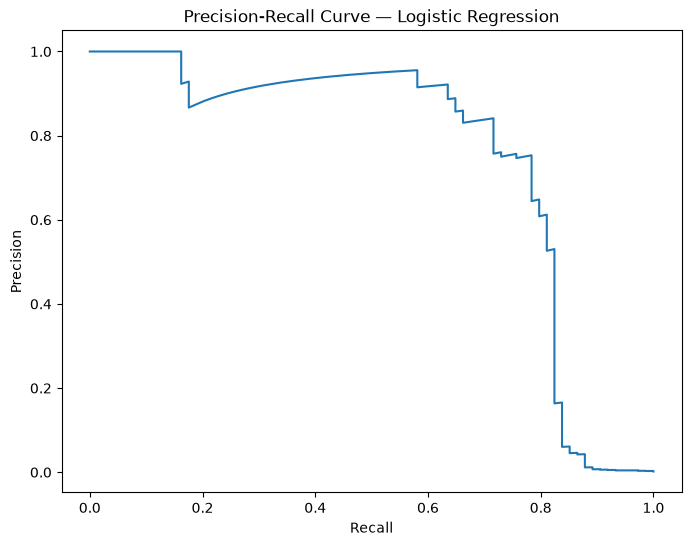

In [23]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    logistic_prob
)
plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Logistic Regression")

plt.show()

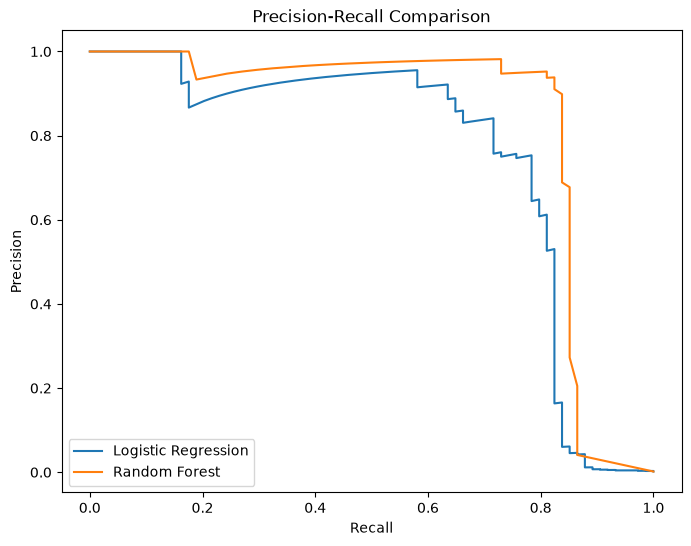

In [24]:
log_precision, log_recall, _ = precision_recall_curve(
    y_test,
    logistic_prob
)

rf_precision, rf_recall, _ = precision_recall_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    log_recall,
    log_precision,
    label="Logistic Regression"
)

plt.plot(
    rf_recall,
    rf_precision,
    label="Random Forest"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Comparison")

plt.legend()
plt.show()

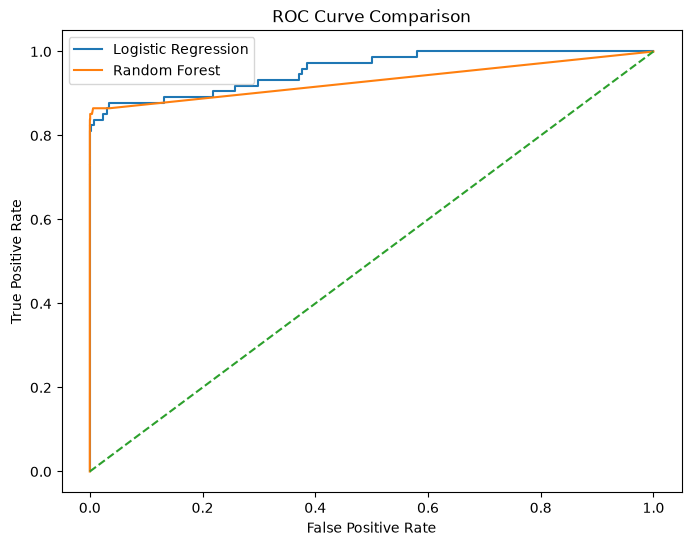

In [25]:
log_fpr, log_tpr, _ = roc_curve(
    y_test,
    logistic_prob
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    log_fpr,
    log_tpr,
    label="Logistic Regression"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

In [26]:
thresholds_to_test = [
    0.50,
    0.30,
    0.20,
    0.10,
    0.05,
    0.02,
    0.01
]
threshold_results = []

for threshold in thresholds_to_test:

    predictions = (
        logistic_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.50,0.921569,0.635135,0.752000
1,0.30,0.844828,0.662162,0.742424
2,0.20,0.836066,0.689189,0.755556
3,0.10,0.779412,0.716216,0.746479
4,0.05,0.750000,0.770270,0.760000
5,0.02,0.600000,0.810811,0.689655
6,0.01,0.371951,0.824324,0.512605


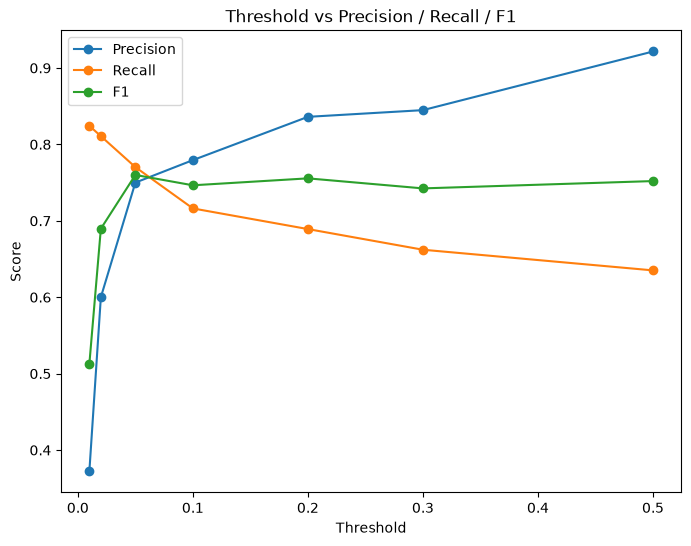

In [27]:
plt.figure(figsize=(8, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision / Recall / F1")

plt.legend()
plt.show()

In [28]:
results.to_csv(
    "../data/processed/baseline_results.csv",
    index=False
)

# Baseline Conclusions

## Dummy Classifier

The dummy classifier demonstrates why accuracy is unreliable for this
highly imbalanced fraud detection problem.

Although it can achieve very high accuracy by predicting the majority
class, it fails to detect fraudulent transactions.

## Logistic Regression

Logistic Regression provides a simple interpretable supervised baseline
and establishes a reference point for precision, recall, F1-score and PR-AUC.

## Random Forest

Random Forest provides a nonlinear ensemble baseline and allows us to
compare a tree-based model against Logistic Regression.

## Evaluation Strategy

Because fraud is extremely rare, PR-AUC, precision, recall and F1-score
are more informative than accuracy alone.

## Threshold

The default 0.5 classification threshold is not necessarily optimal.
Changing the threshold creates a tradeoff between fraud detection
(recall) and false alarms (precision).